# Desafio Praso: Previsão de Risco de Inadimplência

## 1. O que é o projeto
Este projeto é um desafio prático da disciplina de Machine Learning em parceria com a Praso, uma startup que atua facilitando o ciclo de caixa de pequenos varejistas. 

Muitos empreendedores sofrem com a demora para transformar as compras de estoque em vendas (receita). A Praso resolve essa dor oferecendo crédito instantâneo e desburocratizado. Nosso papel neste trabalho é desenvolver o "motor" por trás dessa decisão: um modelo preditivo capaz de estimar a probabilidade de um cliente ficar inadimplente. A qualidade da nossa solução será medida pela capacidade de ordenar bem os clientes em relação ao risco, utilizando a métrica ROC-AUC.

## 2. O que a gente pretende fazer
O desenvolvimento seguirá as etapas fundamentais de um pipeline de Ciência de Dados, conectando a teoria da disciplina com a necessidade de negócio da Praso:

* **Análise Exploratória e Pré-processamento:** Investigar a fundo a base de dados para entender o comportamento das variáveis, tratar valores nulos, lidar com possíveis outliers e resolver o desbalanceamento das classes.
* **Feature Engineering:** Transformar os dados brutos em informações úteis. Faremos a conversão de intervalos de idade do CNPJ para valores contínuos, extrairemos variáveis booleanas (como presença ou não em aplicativos de delivery) e agruparemos dados complexos, como os códigos CNAE e a lista de credores.
* **Modelagem Preditiva:** Desenvolveremos duas abordagens complementares: um "Modelo de Aplicação" (focado em novos clientes, usando dados públicos e da Serasa) e um "Modelo Comportamental" (para clientes recorrentes, agregando o histórico de compras e atrasos).
* **Avaliação e Discussão:** Vamos treinar, otimizar (tunar hiperparâmetros) e comparar pelo menos três algoritmos diferentes, finalizando com uma discussão sobre as limitações e como nossa solução seria aplicada na política de crédito real da startup.

## 3. Explicação dos Datasets
Trabalharemos com bases de dados reais (porém anonimizadas por questões de segurança), que estão divididas em dois contextos principais:

* **Dados Cadastrais e de Risco:** Focados no perfil do estabelecimento comercial no momento do cadastro. Incluem a localização, natureza jurídica, capital social e idade do CNPJ. Também trazem informações externas cruciais, como a presença digital (notas e avaliações no Google Maps e iFood) e o histórico em birôs de crédito (quantidade de negativações, protestos e perfil dos credores na Serasa). A variável alvo de inadimplência pertence a esta base.
* **Dados Comportamentais (Pedidos):** Focados no histórico de relacionamento do cliente com a Praso. Contêm o valor de cada pedido, a data de entrega e o número de dias de atraso no pagamento. Esses dados serão agregados por cliente para entendermos o padrão de pagamento de quem já compra na plataforma.

## 4. Análise Exploratória de Dados (EDA)

Antes de iniciar a modelagem preditiva, é fundamental entender a fundo o comportamento dos dados e como as características dos varejistas se relacionam com o risco de crédito na Praso. Nesta etapa, nossos principais objetivos são:

* **Inspeção de Qualidade:** Identificar e tratar valores faltantes (nulos), duplicatas e possíveis *outliers* que possam prejudicar a inteligência do modelo.
* **Avaliação da Variável Alvo:** Analisar o grau de desbalanceamento da classe `inadimplente` (0 = Não, 1 = Sim) para guiar nossas métricas de avaliação (como ROC-AUC).
* **Análise Bivariada e Hipóteses:** Relacionar variáveis cadastrais (ex: negativações na Serasa, segmento, idade do CNPJ) e comportamentais (ex: média de atraso nos pedidos) com a taxa de inadimplência, gerando *insights* e preparando o terreno para a *Feature Engineering*.

### 4.1. Configuração Inicial e Carregamento dos Dados

**Objetivo da Análise:** 
Preparar o nosso ambiente de trabalho. Aqui, importaremos as bibliotecas fundamentais para a manipulação e visualização dos dados (`pandas`, `matplotlib` e `seaborn`). Em seguida, faremos a leitura das duas bases fornecidas pela Praso: a tabela de cadastro/risco dos clientes e a tabela de histórico comportamental de pedidos.

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df_clientes = pd.read_csv('credito_aplicacao_clientes_final.csv') 
df_pedidos = pd.read_csv('credito_comportamental_pedidos_final.csv')

### 4.2. Análise da Variável Alvo: Verificando o Desbalanceamento

**Objetivo da Análise:** 
Entender a distribuição da nossa variável dependente (`inadimplente`). O desafio pede uma atenção especial ao desbalanceamento das classes, pois em problemas de concessão de crédito, é comum termos muito mais "bons pagadores" (0) do que "maus pagadores" (1). Compreender essa proporção ditará a necessidade de técnicas de balanceamento mais à frente e justifica o uso do **ROC-AUC** como métrica principal de avaliação.

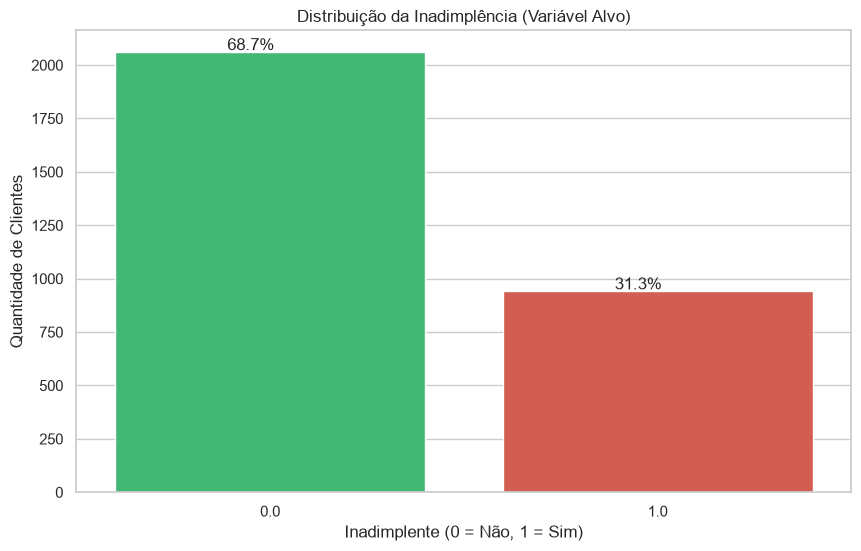

In [145]:
ax = sns.countplot(data=df_clientes, x='inadimplente', palette=['#2ecc71', '#e74c3c'],hue='inadimplente', legend=False)
plt.title('Distribuição da Inadimplência (Variável Alvo)')
plt.xlabel('Inadimplente (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Clientes')


total = len(df_clientes)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 10
    ax.annotate(percentage, (x, y), ha='center')

plt.show()

### Análise dos Resultados: Distribuição da Variável Alvo

Com base no gráfico gerado, identificamos o comportamento da nossa variável alvo (`inadimplente`) no dataset:

* **Adimplentes (0.0):** Representam a maioria da base, totalizando **68,7%** dos clientes (bons pagadores).
* **Inadimplentes (1.0):** Representam a minoria, correspondendo a **31,3%** dos clientes.

**Principais Insights e Implicações para a Modelagem:**

1. **Desbalanceamento Moderado:** O dataset apresenta um desbalanceamento aproximado de 2:1. Embora seja comum em problemas de crédito ter mais "bons" do que "maus" pagadores, uma taxa de inadimplência na casa dos 31% é considerada alta para padrões de mercado tradicionais. Isso ilustra perfeitamente o cenário da Praso: ao desburocratizar o crédito para pequenos varejistas sem exigir histórico extenso, a startup assume um risco maior, tornando a assertividade do nosso modelo preditivo vital para a saúde financeira do negócio.
2. **A "Armadilha" da Acurácia:** Devido a esse desbalanceamento, a métrica de Acurácia tradicional será ilusória. Se criarmos um modelo "burro" que simplesmente preveja que *nenhum* cliente ficará inadimplente (chutando 0 para todos), ele terá quase 69% de acerto. Isso mascararia o nosso real problema: identificar os maus pagadores.
3. **Validação do ROC-AUC:** Esse cenário comprova a necessidade de utilizarmos o **ROC-AUC** como métrica principal de avaliação, conforme exigido no desafio. O ROC-AUC mede a capacidade do modelo de distinguir entre as duas classes e ordená-las corretamente em um *score* de risco, o que é imune ao desbalanceamento das proporções.
4. **Estratégias Futuras:** Na etapa de modelagem, precisaremos testar estratégias para lidar com essa diferença de representatividade, como o uso de pesos balanceados nos algoritmos (ex: `class_weight='balanced'`) ou técnicas de reamostragem (como o SMOTE ou undersampling).

### 4.3. Mapeamento de Dados Faltantes

**Objetivo da Análise:** 
Identificar o volume e a localização dos dados faltantes em nossa base. Segundo o material do desafio, na Praso, a ausência de um dado pode ser uma informação valiosa por si só. Por exemplo, a ausência de informações nas variáveis `ifood_contagem_avaliacoes` ou `google_maps_avaliacao` nos diz que o cliente não possui presença nessas plataformas. Mapear isso agora é o primeiro passo para criarmos variáveis booleanas (Tem/Não tem) na fase de *Feature Engineering*.

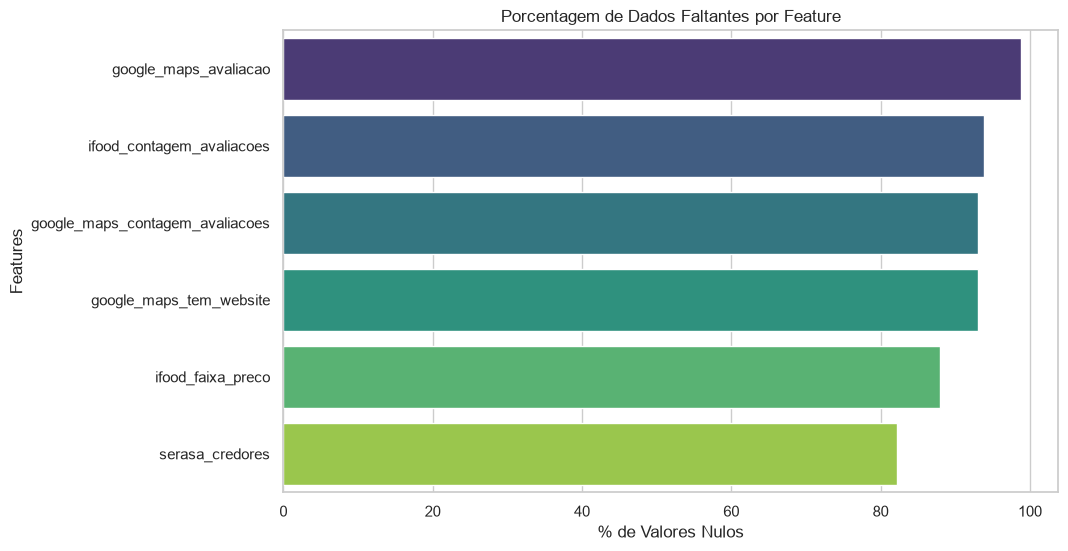

In [146]:
nulos_percentual = (df_clientes.isnull().sum() / len(df_clientes)) * 100
nulos_percentual = nulos_percentual[nulos_percentual > 0].sort_values(ascending=False)

if not nulos_percentual.empty:
    sns.barplot(x=nulos_percentual.values, y=nulos_percentual.index, palette='viridis', legend=False, hue=nulos_percentual.index,)
    plt.title('Porcentagem de Dados Faltantes por Feature')
    plt.xlabel('% de Valores Nulos')
    plt.ylabel('Features')
    plt.show()
else:
    print("Nenhum dado faltante encontrado!")

### Análise dos Resultados: Tratamento de Dados Faltantes (Valores Nulos)

O gráfico acima revela que todas as colunas que apresentam valores nulos em nossa base possuem uma taxa de ausência altíssima (acima de 80%). Observando as variáveis afetadas, notamos que elas pertencem a três categorias principais de fontes externas: **Google Maps**, **iFood** e **Serasa**.

**Principais Insights e Estratégia de Feature Engineering:**

1. **Ausência Estrutural (Missing Not at Random):**
   * Se um cliente tem valor nulo em `Maps_avaliacao`, significa que o estabelecimento não possui presença mapeada no Google.
   * Se tem nulo em `ifood_contagem_avaliacoes`, o cliente não está cadastrado no app de delivery.
   * Se `serasa_credores` é nulo, significa que o cliente não possui dívidas registradas com outras empresas naquele momento.

2. **Criação de Variáveis Booleanas (Flags):** Conforme sugerido nas diretrizes do desafio da Praso, não vamos excluir essas colunas. Em vez disso, usaremos a etapa de *Feature Engineering* para criar novas variáveis booleanas. 
   * Exemplo: Criar a variável `presenca_ifood` (onde 1 = tem dados no iFood; 0 = valor nulo). 
   * A hipótese de negócio aqui é clara: estabelecimentos com presença digital ativa (iFood, Google Maps) tendem a ser mais estruturados e, possivelmente, apresentam menor risco de crédito.

3. **Tratamento dos Valores Originais:** Após criarmos as variáveis booleanas para indicar a "presença", precisaremos preencher os valores vazios nas colunas originais para que os algoritmos de funcionem corretamente. Podemos preencher numéricos com `-1` (indicando ausência) e categóricos com a string `"Desconhecido"`.

### 4.4. Segmento do Cliente e Risco

**Objetivo da Análise:** 
Analisar como as características cadastrais e o histórico de crédito prévio se relacionam com o fato de o cliente não pagar a Praso. Conforme sugerido no escopo do projeto, vamos comparar as taxas de inadimplência entre os diferentes `segmento_cliente` (ex: Padarias vs. Hotéis) e verificar se restrições nos birôs (como `serasa_socio_tem_negativacao`) são, de fato, fortes indicativos.

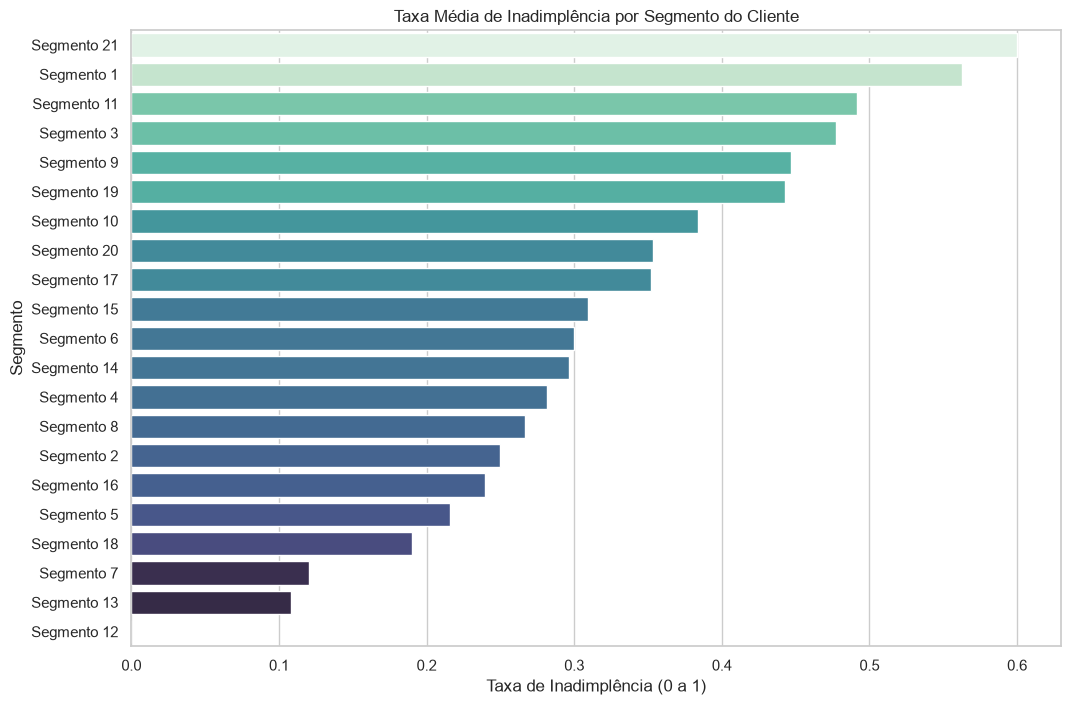

In [147]:
segmento_inadimplencia = df_clientes.groupby('segmento_cliente')['inadimplente'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=segmento_inadimplencia, x='inadimplente', y='segmento_cliente', palette='mako', hue='inadimplente', legend=False)
plt.title('Taxa Média de Inadimplência por Segmento do Cliente')
plt.xlabel('Taxa de Inadimplência (0 a 1)')
plt.ylabel('Segmento')
plt.show()

### Análise dos Resultados: Taxa de Inadimplência por Segmento

O gráfico de barras ilustra a taxa média de inadimplência agrupada pelos 21 segmentos de clientes anonimizados da base. Fica evidente que o nicho de atuação do varejista tem um impacto direto e drástico na probabilidade de inadimplência.

**Principais Insights e Implicações para a Modelagem:**

1. **Disparidade Extrema de Risco:** Existe uma variação massiva de risco entre as pontas. 
   * Os **Segmentos 21 e 1** são os mais críticos, apresentando taxas de inadimplência alarmantes de aproximadamente 60% e 56%, respectivamente. Mais da metade dos clientes desses grupos não pagam.
   * Em contrapartida, os **Segmentos 12, 13 e 7** são extremamente seguros. O Segmento 12 beira o 0% de inadimplência, enquanto o 13 e o 7 ficam na faixa dos 10% a 13%.
2. **Alto Poder Preditivo:** Por apresentar tanta variância em relação à variável alvo, `segmento_cliente` será uma das *features* (variáveis) mais importantes para o nosso algoritmo. O modelo facilmente aprenderá a penalizar o *score* de crédito do Segmento 21 e beneficiar o do Segmento 12.
3. **Atenção ao Overfitting (Estratégia de Modelagem):** Como temos 21 categorias numéricas anonimizadas, precisaremos converter esses dados adequadamente (por exemplo, usando *One-Hot Encoding* ou *Target Encoding*). Contudo, devemos verificar se os segmentos nos extremos (como o 12 e o 21) possuem um volume de clientes representativo. Se o Segmento 12 tiver apenas 2 clientes na base toda, essa taxa de 0% pode ser uma armadilha estatística (*overfitting*).
4. **Implicações Práticas para a Praso:** Do ponto de vista de negócios, essas informações permitem a criação de **políticas de crédito segmentadas**. A Praso poderia, por exemplo, exigir um fiador ou reduzir o limite inicial de crédito para clientes do Segmento 21, enquanto libera crédito pré-aprovado mais elástico para o Segmento 13, melhorando a experiência do bom pagador.

### 4.5. Impacto de Sócios Negativados na Serasa

**Objetivo da Análise:**
Nesta etapa, vamos investigar a relação direta entre o histórico de crédito dos proprietários (Pessoa Física) e o risco da empresa (Pessoa Jurídica). A variável `serasa_socio_tem_negativacao` é uma flag booleana. A nossa hipótese de negócio aqui é clara: empreendedores que possuem restrições ativas em seu próprio CPF (na Serasa) tendem a apresentar um risco de inadimplência consideravelmente maior quando buscam crédito para o seu CNPJ na Praso. Vamos validar isso visualmente.

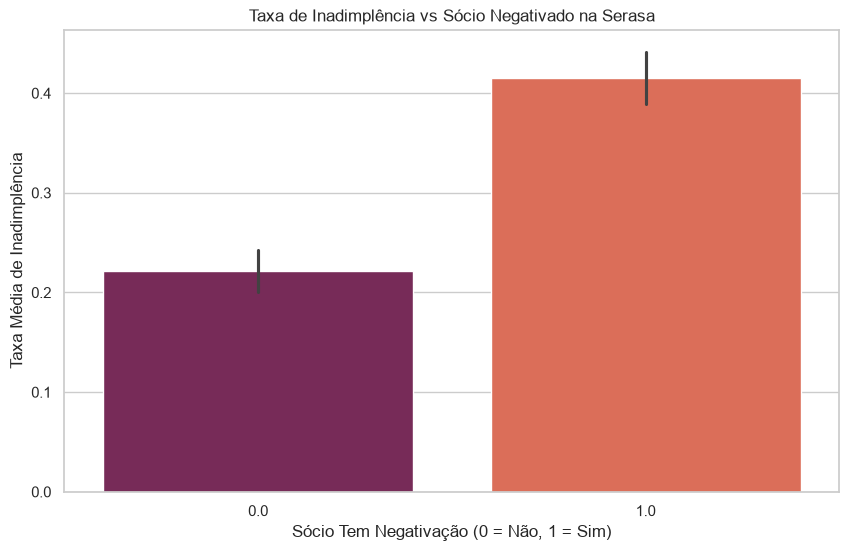

In [148]:
sns.barplot(data=df_clientes, x='serasa_socio_tem_negativacao', y='inadimplente', palette='rocket', legend= False, hue ='serasa_socio_tem_negativacao' )
plt.title('Taxa de Inadimplência vs Sócio Negativado na Serasa')
plt.xlabel('Sócio Tem Negativação (0 = Não, 1 = Sim)')
plt.ylabel('Taxa Média de Inadimplência')
plt.show()

### Análise dos Resultados: Sócio Negativado na Serasa

O gráfico acima cruza a taxa média de inadimplência da empresa com o fato de algum de seus sócios possuir uma negativação ativa junto à Serasa. 

**Principais Insights e Implicações para a Modelagem:**

1. **Validação da Hipótese de Contágio de Risco:** A nossa hipótese inicial foi fortemente confirmada. Quando o sócio **não tem** negativação (0.0), a taxa de inadimplência da empresa na Praso fica um pouco acima dos 20%. No entanto, quando o sócio **tem** uma negativação (1.0), essa taxa praticamente dobra, ultrapassando a marca dos 40%.
2. **Mistura de PFs e PJs no Pequeno Varejo:** Esse comportamento é muito característico do pequeno varejo brasileiro. Na prática financeira, o caixa do dono (Pessoa Física) muitas vezes se confunde com o caixa da empresa (Pessoa Jurídica). Se o empreendedor já está inadimplente em suas contas pessoais, a probabilidade de o CNPJ também não conseguir honrar seus compromissos com fornecedores (como a Praso) aumenta drasticamente.
3. **Poder da Variável no Modelo:** A variável `serasa_socio_tem_negativacao` provou ser um excelente preditor (uma *feature* de alto peso). Como ela já está em formato booleano (0 e 1) e apresenta uma separação estatística clara (indicada pelos curtos intervalos de confiança que não se cruzam), ela poderá ser injetada quase diretamente no nosso modelo de *Machine Learning*.
4. **Impacto na Aplicação de Negócio:** Na política de crédito da Praso (para o Modelo de Aplicação focado em novos clientes), essa variável pode atuar como um filtro inicial (uma regra de *cut-off*). Clientes com sócios negativados podem ter um teto de crédito inicial mais conservador até que provem um bom comportamento de pagamento nos primeiros pedidos.

### 4.6. Maturidade do Negócio vs. Risco: Avaliando as Faixas de Idade do CNPJ

**Objetivo da Análise:** 
O objetivo desta etapa é visualizar o volume de clientes dentro de cada faixa de idade e cruzar essa informação com a taxa de inadimplência média daquele grupo.

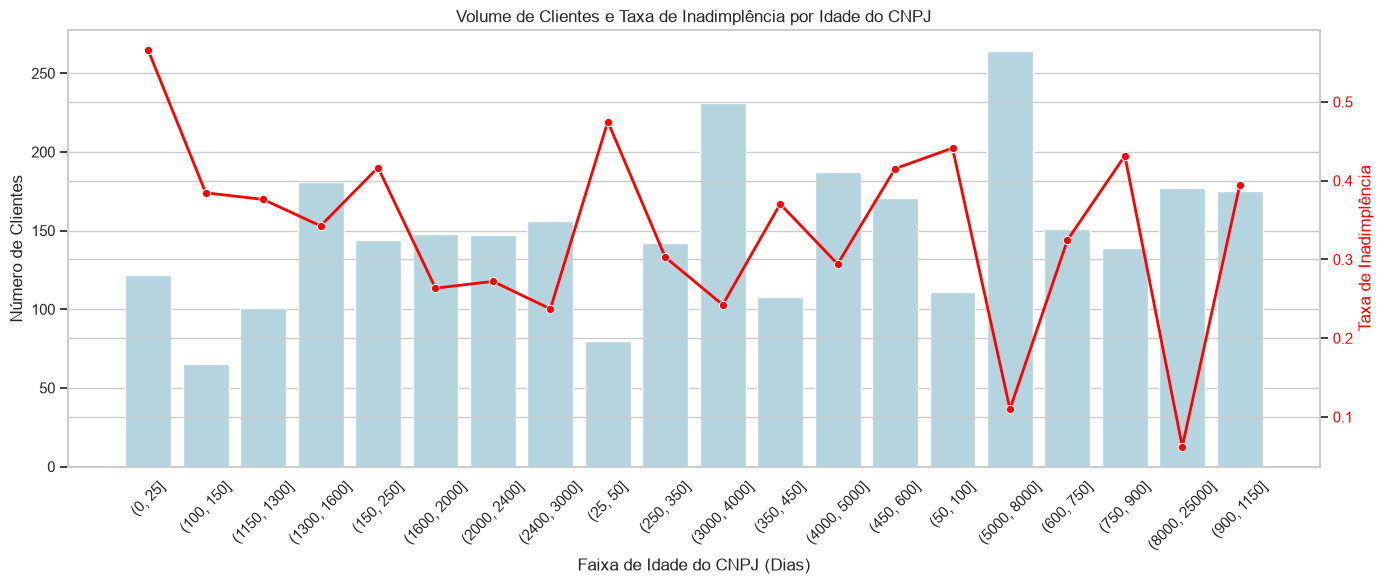

In [149]:
ordem_idade = sorted(df_clientes['idade_cnpj'].dropna().unique().tolist())

fig, ax1 = plt.subplots(figsize=(14, 6))


sns.countplot(data=df_clientes, x='idade_cnpj', order=ordem_idade, color='lightblue', ax=ax1)
ax1.set_ylabel('Número de Clientes')
ax1.set_xlabel('Faixa de Idade do CNPJ (Dias)')
plt.xticks(rotation=45)


ax2 = ax1.twinx()
taxa_idade = df_clientes.groupby('idade_cnpj')['inadimplente'].mean()[ordem_idade]
sns.lineplot(x=taxa_idade.index, y=taxa_idade.values, color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('Taxa de Inadimplência', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Volume de Clientes e Taxa de Inadimplência por Idade do CNPJ')
plt.tight_layout()
plt.show()

### Análise dos Resultados: Maturidade do Negócio vs. Risco

O gráfico misto acima sobrepõe o volume de clientes (barras) e a taxa de inadimplência (linha vermelha) agrupados pelas faixas de idade do CNPJ. 

**Principais Insights e Implicações para a Modelagem:**

1. **O Risco dos Negócios "Recém-Nascidos":** O ponto que mais chama a atenção é o extremo esquerdo do gráfico, na faixa `(0, 25]`. Empresas com menos de um mês de existência (desde a abertura na Sefaz até o cadastro na Praso) apresentam o maior pico de risco da base, com uma inadimplência que ultrapassa os 50%. Isso reflete perfeitamente a realidade do pequeno varejo: negócios em estágio inicial sofrem com alta volatilidade e falta de fluxo de caixa consolidado.
2. **Erro da Ordem Alfabética:** Ao analisar a linha de tendência, nota-se um comportamento errático (zigue-zague). Isso ocorreu porque as faixas (por estarem em formato de texto/string) foram plotadas em ordem alfabética lexicográfica (ex: o caractere "1150" foi colocado antes de "150"), e não em ordem cronológica contínua. Por conta disso, a curva real de amadurecimento do risco com o passar do tempo ficou ofuscada.
3. **Estratégia de Feature Engineering:** Conforme sugerido nas diretrizes do desafio, a melhor forma de contornar esse problema e gerar valor para o modelo de Machine Learning é realizar uma transformação desses dados. Na próxima fase, vamos converter essas categorias de texto em variáveis contínuas, extraindo o **ponto médio** de cada intervalo. Por exemplo, a faixa `(150, 250]` será transformada no número `200`. Isso corrigirá nossa ordenação e permitirá que o algoritmo entenda perfeitamente a grandeza numérica da "idade" da empresa.

### 4.7. Modelo Comportamental: Impacto do Histórico de Pedidos e Atrasos

**Objetivo da Análise:** 
Para a construção do Modelo Comportamental, o desafio exige a criação de variáveis agregadas a partir do histórico de compras. O objetivo desta célula é analisar a base `credito_comportamental_pedidos_final.csv`, extraindo métricas a nível de cliente, como o *atraso médio* e o *volume total comprado*. A ideia é verificar visualmente se clientes que atrasam os primeiros pedidos têm maior probabilidade de virar inadimplentes definitivos.

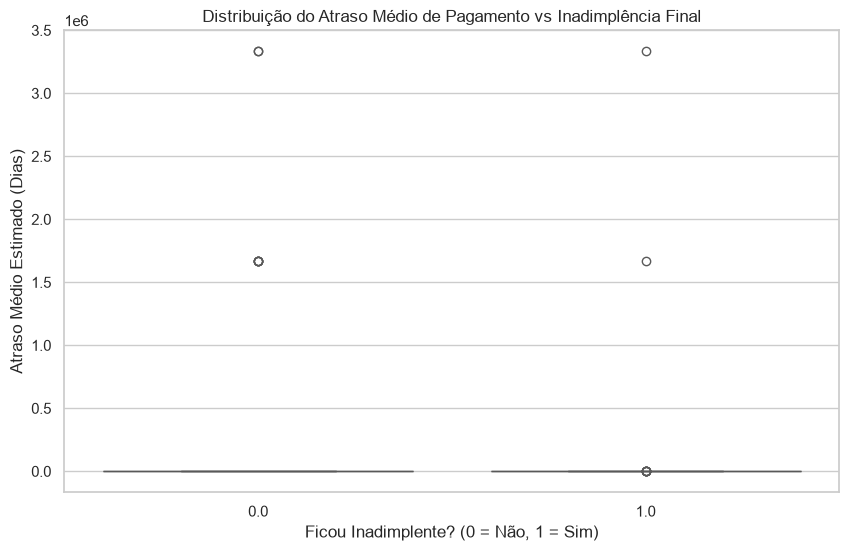

In [150]:

def extrair_ponto_medio(intervalo):
    if pd.isna(intervalo):
        return np.nan
    
    texto = str(intervalo)
    
    if ',' in texto:
        texto_limpo = texto.replace('(', '').replace('[', '').replace(']', '').replace(')', '')
        partes = texto_limpo.split(',')
        try:
            return (float(partes[0]) + float(partes[1])) / 2
        except:
            return np.nan
    try:
        return float(texto)
    except:
        return np.nan
    
def limpa_id(x):
    try:
        return str(int(float(x)))
    except:
        return str(x).strip()

df_clientes['id_cliente_clean'] = df_clientes['id_cliente'].apply(limpa_id)
df_pedidos['id_cliente_clean'] = df_pedidos['id_cliente'].apply(limpa_id)

df_pedidos['atraso_numerico'] = df_pedidos['atraso'].apply(extrair_ponto_medio)
df_pedidos['valor'] = pd.to_numeric(df_pedidos['valor'], errors='coerce')


df_comportamento = df_pedidos.groupby('id_cliente_clean').agg(
    valor_total_gasto=('valor', 'sum'),
    atraso_medio=('atraso_numerico', 'mean'),
    quantidade_pedidos=('id_pedido', 'count')
).reset_index()


df_analise_comportamento = df_clientes[['id_cliente_clean', 'inadimplente']].merge(
    df_comportamento, on='id_cliente_clean', how='inner'
)

df_plot = df_analise_comportamento.dropna(subset=['atraso_medio'])


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot, 
    x='inadimplente', 
    y='atraso_medio', 
    hue='inadimplente',
    palette='Set2',
    legend=False
)
plt.title('Distribuição do Atraso Médio de Pagamento vs Inadimplência Final')
plt.xlabel('Ficou Inadimplente? (0 = Não, 1 = Sim)')
plt.ylabel('Atraso Médio Estimado (Dias)')
plt.ylabel('Atraso Médio Estimado (Dias)') 
plt.show()


### Análise dos Resultados: Comportamento de Pagamento e Descoberta de Outliers

Ao gerarmos o primeiro boxplot do histórico de atrasos, nos deparamos com uma situação clássica do trabalho com dados reais: a presença de *outliers* extremos.

**Principais Insights e Implicações para a Modelagem:**

1. **Anomalias na Base de Dados:** O gráfico original revelou registros com atrasos médios na casa dos milhões de dias. Como isso é cronologicamente impossível, trata-se claramente de um artefato de erro do sistema de origem. 
2. **Impacto na Modelagem:** Descobrir isso agora é crucial. Se alimentarmos um modelo com um atraso de "3 milhões de dias", o modelo ficará totalmente enviesado.
3. **Estratégia de Limpeza:** Na próxima fase de pré-processamento, será fundamental aplicar um filtro para remover ou limitar esses valores absurdos, garantindo que o algoritmo aprenda apenas com o comportamento humano real.

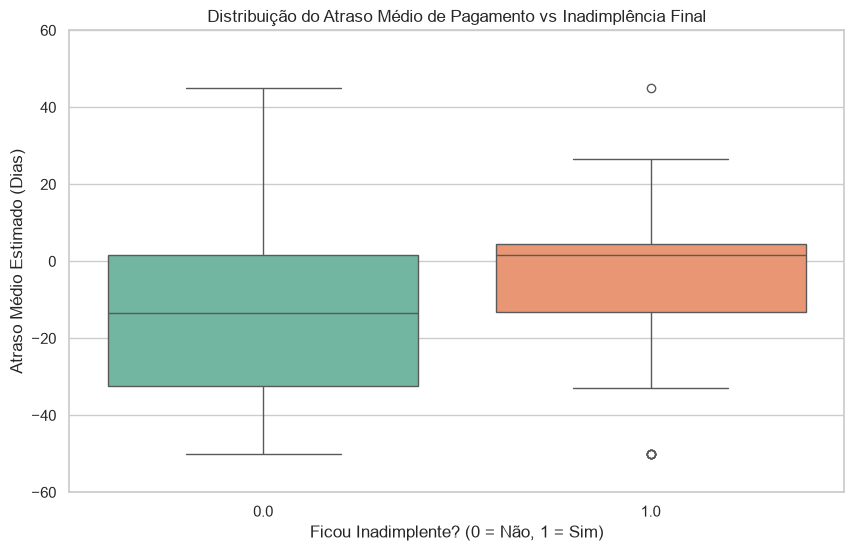

In [151]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot, 
    x='inadimplente', 
    y='atraso_medio', 
    hue='inadimplente',
    palette='Set2',
    legend=False
)
plt.title('Distribuição do Atraso Médio de Pagamento vs Inadimplência Final')
plt.xlabel('Ficou Inadimplente? (0 = Não, 1 = Sim)')
plt.ylabel('Atraso Médio Estimado (Dias)')
plt.ylabel('Atraso Médio Estimado (Dias)') 
plt.ylim(-60, 60)
plt.show()

### Análise dos Resultados: Comportamento Real de Pagamento

**Principais Insights e Implicações para a Modelagem:**

1. **Atraso Negativo:** Um "atraso negativo" significa que o cliente pagou o boleto antes da data de vencimento. Observando a caixa verde, a mediana está na faixa de -15 dias. O intervalo interquartil mostra que a grande maioria deles paga muito antes do prazo.
2. **O Perfil do Inadimplente:** Quando olhamos para a caixa laranja, notamos um deslocamento claro para cima. A mediana salta para perto do 0  ou ligeiramente positivo. O grupo que futuramente poderá se torna inadimplente costuma usar o prazo de crédito até o limite ou atrasa alguns dias já nas compras anteriores.
3. **Alto Poder Preditivo:** A distância visual entre as medianas prova que a variável `atraso_medio` será importante para o nosso Modelo Comportamental.

## 5. Feature Engineering: Pré-processamento e Criação de Variáveis

 
Nesta fase, vamos transformar os dados brutos em formatos matemáticos otimizados para que os algoritmos de Machine Learning consigam aprender e extrair o máximo de poder preditivo. Nosso plano de ação está dividido nas seguintes frentes:

### 5.1. Presença Digital e o Valor dos Dados Nulos
Durante a EDA, descobrimos que colunas referentes ao iFood, Google Maps e Credores possuíam altas taxas de valores nulos. Entendemos que essa ausência não é um erro do sistema, mas sim uma característica valiosa do negócio.
* **Criação de Flags Booleanas:** Vamos gerar novas variáveis binárias (ex: `flag_tem_ifood`, `flag_tem_google`, `flag_tem_credores`) onde 1 indica presença do dado e 0 indica ausência.

### 5.2. Transformação de Intervalos em Variáveis Contínuas
A idade da empresa (`idade_cnpj`) e o atraso dos pedidos vieram ofuscados em formato de intervalos de texto (ex: `(150, 250]`), o que impede o cálculo matemático direto pelos modelos.
* **Cálculo do Ponto Médio:** Atendendo a uma sugestão direta do desafio, aplicaremos uma transformação para extrair os limites desses textos e calcular o ponto médio. Por exemplo, a faixa `(150, 250]` se transformará no valor numérico contínuo `200.0`.

### 5.3. Histórico de Crédito (Serasa)
As restrições de crédito provaram ter um alto poder de separação entre bons e maus pagadores na nossa análise bivariada.
* **Contagem de Credores:** A coluna `serasa_credores` traz uma lista descritiva em texto (ex: "Alimentos e Bebidas, Distribuição"). Transformaremos isso em uma variável quantitativa (`qtd_credores`), contando o número exato de empresas distintas para as quais o cliente deve, fornecendo um termômetro claro da gravidade do endividamento.

### 5.4. Agregação Comportamental (Histórico de Pedidos)
Para viabilizar o Modelo Comportamental, cruzaremos a base de clientes com o histórico de compras.
* **Métricas Agregadas por Cliente:** Após filtrarmos dados anômalos , calcularemos o valor total gasto, a quantidade de pedidos e o atraso médio estimado, consolidando essas informações como features numéricas exclusivas de cada comprador.

In [152]:
df_clientes['idade_cnpj_numerica'] = df_clientes['idade_cnpj'].apply(extrair_ponto_medio)
df_clientes['idade_cnpj_numerica'] = df_clientes['idade_cnpj'].apply(extrair_ponto_medio)
df_clientes['capital_social_numerico'] = df_clientes['capital_social'].apply(extrair_ponto_medio)  # <- adiciona essa
df_clientes['flag_tem_ifood'] = df_clientes['ifood_contagem_avaliacoes'].apply(lambda x: 0 if pd.isna(x) or x == -1 else 1)
df_clientes['flag_tem_google'] = df_clientes['google_maps_avaliacao'].apply(lambda x: 0 if pd.isna(x) or x == -1 else 1)
df_clientes['flag_tem_credores'] = df_clientes['serasa_credores'].notna().astype(int)

def contar_credores(lista_credores):
    if pd.isna(lista_credores): return 0
    return len(str(lista_credores).split(','))

df_clientes['qtd_credores'] = df_clientes['serasa_credores'].apply(contar_credores)

df_clientes['ifood_contagem_avaliacoes'] = df_clientes['ifood_contagem_avaliacoes'].fillna(-1)
df_clientes['google_maps_avaliacao'] = df_clientes['google_maps_avaliacao'].fillna(-1)
df_clientes['google_maps_contagem_avaliacoes'] = df_clientes['google_maps_contagem_avaliacoes'].fillna(-1)

capitais = ['RECIFE', 'FORTALEZA', 'JOAO PESSOA']
regiao_metropolitana = [
    'JABOATAO DOS GUARARAPES', 'OLINDA', 'PAULISTA', 'CAMARAGIBE', 
    'CAUCAIA', 'MARACANAU', 'EUSEBIO', 'CABEDELO', 'SANTA RITA', 'BAYEUX'
]

def classificar_regiao(cidade):
    if pd.isna(cidade): return 'DESCONHECIDO'
    cidade_limpa = str(cidade).upper().strip()
    if cidade_limpa in capitais: return 'CAPITAL'
    elif cidade_limpa in regiao_metropolitana: return 'REGIAO_METROPOLITANA'
    return 'INTERIOR'

df_clientes['regiao_geografica'] = df_clientes['municipio'].apply(classificar_regiao)

def extrair_hierarquia_cnae(cnae):
    if pd.isna(cnae):
        return pd.Series({'cnae_divisao': 'DESCONHECIDO', 'cnae_grupo': 'DESCONHECIDO'})
    cnae_str = str(cnae).strip()
    try:
        divisao = cnae_str[:2]
        grupo = cnae_str[:5]
        return pd.Series({'cnae_divisao': divisao, 'cnae_grupo': grupo})
    except:
        return pd.Series({'cnae_divisao': 'DESCONHECIDO', 'cnae_grupo': 'DESCONHECIDO'})

df_clientes[['cnae_divisao', 'cnae_grupo']] = df_clientes['cnae_codigo'].apply(extrair_hierarquia_cnae)

mapeamento_ifood = {'$': 1, '$$': 2, '$$$': 3, '$$$$': 4, '$$$$$': 5}
df_clientes['ifood_faixa_preco_num'] = df_clientes['ifood_faixa_preco'].map(mapeamento_ifood).fillna(0)

base_modelo_aplicacao = df_clientes.copy()

LIMITE_ATRASO_DIAS = 365
df_pedidos_limpos = df_pedidos[
    df_pedidos['atraso_numerico'].isna() | 
    (df_pedidos['atraso_numerico'] < LIMITE_ATRASO_DIAS)
].copy()

df_pedidos_limpos['pedido_atrasou'] = (df_pedidos_limpos['atraso_numerico'] > 0).astype(int)

data_maxima_base = pd.to_datetime(df_pedidos_limpos['data_entrega'], format='%Y-%m-%d', errors='coerce').max()
df_pedidos_limpos['data_pedido_dt'] = pd.to_datetime(df_pedidos_limpos['data_entrega'], format='%Y-%m-%d', errors='coerce')

df_comportamento_final = df_pedidos_limpos.groupby('id_cliente_clean').agg(
    valor_total_gasto=('valor', 'sum'),
    ticket_medio=('valor', 'mean'),
    atraso_medio=('atraso_numerico', 'mean'),
    quantidade_pedidos=('id_pedido', 'count'),
    proporcao_pedidos_atraso=('pedido_atrasou', 'mean'),
    data_ultima_compra=('data_pedido_dt', 'max')
).reset_index()

df_comportamento_final['dias_sem_comprar'] = (data_maxima_base - df_comportamento_final['data_ultima_compra']).dt.days
df_comportamento_final.drop(columns=['data_ultima_compra'], inplace=True, errors='ignore')
df_comportamento_final['proporcao_pedidos_atraso'] *= 100

base_modelo_comportamental = base_modelo_aplicacao.merge(
    df_comportamento_final, on='id_cliente_clean', how='inner'
)

print("--- PREPARAÇÃO CONCLUÍDA COM SUCESSO ---")
print(f"Modelo de Aplicação: {base_modelo_aplicacao.shape[0]} clientes")
print(f"Modelo Comportamental: {base_modelo_comportamental.shape[0]} clientes")
print(f"\nPedidos originais: {len(df_pedidos)}")
print(f"Pedidos após remoção de outliers: {len(df_pedidos_limpos)}")
print(f"Outliers removidos: {len(df_pedidos) - len(df_pedidos_limpos)}")

--- PREPARAÇÃO CONCLUÍDA COM SUCESSO ---
Modelo de Aplicação: 3000 clientes
Modelo Comportamental: 664 clientes

Pedidos originais: 1977
Pedidos após remoção de outliers: 1965
Outliers removidos: 12


### 5.5. Análise de Multicolinearidade

Para evitar redundâncias, calculamos a Correlação de Pearson entre as principais variáveis numéricas contínuas e as flags que construímos.

O objetivo principal desta etapa é investigar se as variáveis derivadas de negativação (`qtd_credores`, `flag_tem_credores`, etc.) sofrem de multicolinearidade extrema, o que poderia distorcer os coeficientes dos algoritmos lineares. Além disso, buscamos validar matematicamente quais atributos possuem a maior correlação direta com a nossa variável alvo (`inadimplente`).

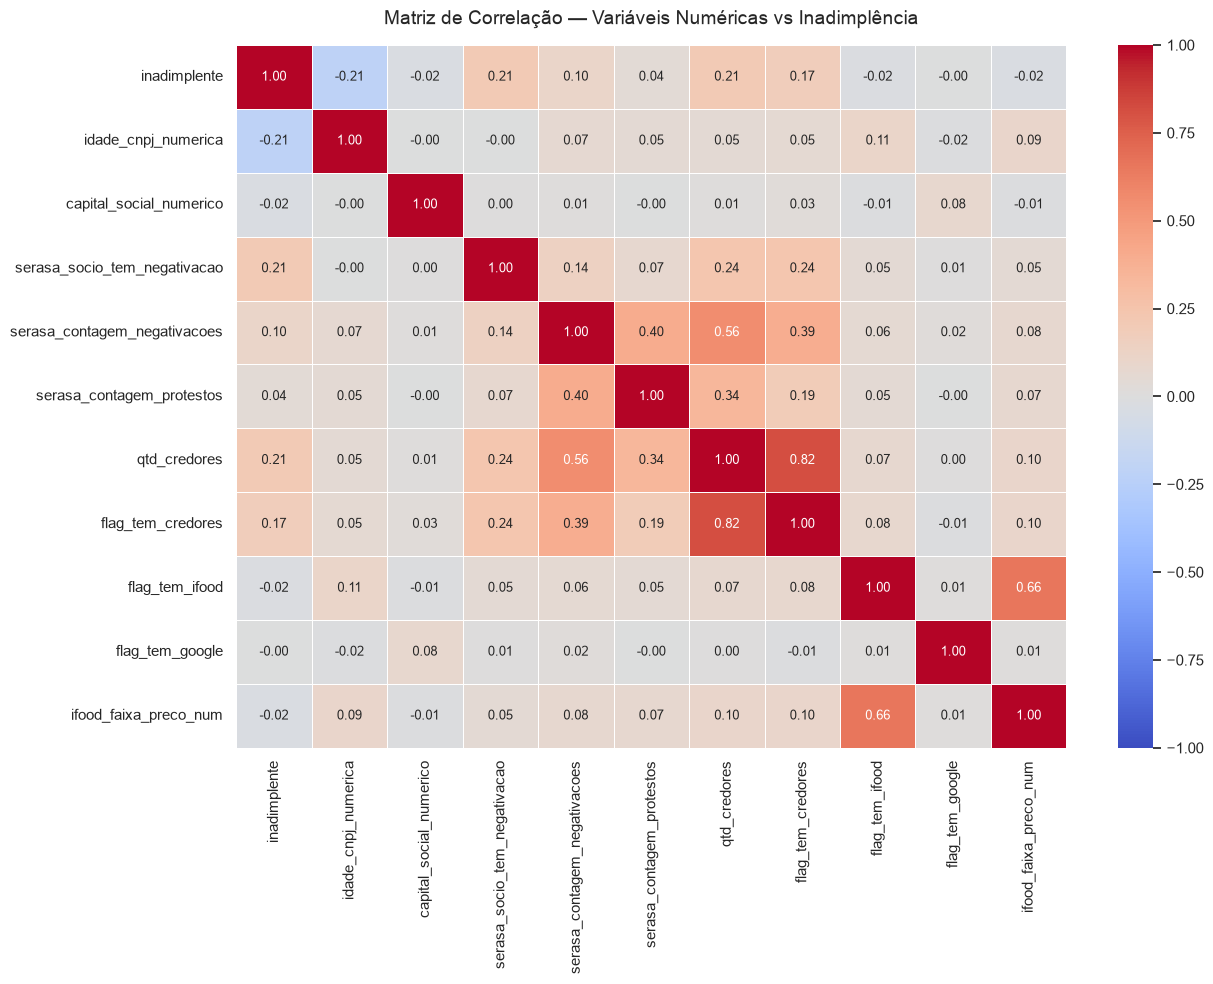

In [153]:
colunas_numericas = [
    'inadimplente',
    'idade_cnpj_numerica',
    'capital_social_numerico',
    'serasa_socio_tem_negativacao',
    'serasa_contagem_negativacoes',
    'serasa_contagem_protestos',
    'qtd_credores',
    'flag_tem_credores',
    'flag_tem_ifood',
    'flag_tem_google',
    'ifood_faixa_preco_num',
]

colunas_existentes = [c for c in colunas_numericas if c in base_modelo_aplicacao.columns]

df_corr = base_modelo_aplicacao[colunas_existentes].apply(pd.to_numeric, errors='coerce')
matriz_correlacao = df_corr.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 9}
)
plt.title('Matriz de Correlação — Variáveis Numéricas vs Inadimplência', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Análise Diagnóstica do Heatmap

A Matriz de Correlação expandida confirma graficamente as nossas hipóteses de negócio e valida a nossa Engenharia de Atributos:

**1. A Força Preditiva do Histórico de Crédito e da Idade:**
As variáveis com maior correlação direta com a inadimplência são `serasa_socio_tem_negativacao` (+0.21), `qtd_credores` (+0.21) e `idade_cnpj_numerica` (-0.21). Isso confirma que o comportamento de crédito do sócio Pessoa Física, o nível de endividamento da empresa e o tempo de existência do CNPJ são os três pilares fundamentais do risco na plataforma. A variável `flag_tem_credores` também contribui com +0.17, reforçando que até a simples existência de uma dívida já é um sinal de alerta relevante.

**2. A Questão da Multicolinearidade:**
Observamos uma alta correlação (**0.82**) entre `qtd_credores` e `flag_tem_credores`. Isso era matematicamente esperado, pois ambas derivam do mesmo fenômeno na Serasa. Decidimos manter ambas as variáveis no pipeline de treinamento: os modelos baseados em árvores (Random Forest e XGBoost) lidam de forma robusta com atributos colineares, e a diferença entre "ter uma dívida" e a "quantidade de dívidas" pode carregar nuances vitais em nós profundos da árvore. Identificamos também correlação moderada (0.40) entre `serasa_contagem_negativacoes` e `serasa_contagem_protestos`, o que faz sentido pois ambas medem restrições de crédito em dimensões diferentes.

**3. Capital Social com Baixo Poder Isolado:**
A variável `capital_social_numerico` apresentou correlação de apenas -0.02 com a inadimplência. Isso indica que o valor investido pelos sócios, por si só, não é um bom preditor de risco nesta base — possivelmente porque muitos pequenos varejistas abrem CNPJs com capital social mínimo independentemente do seu perfil de pagamento. A variável será mantida no modelo, pois pode ter valor preditivo em combinações não-lineares.

**4. Independência das Variáveis Digitais:**
As flags de presença digital (`flag_tem_ifood`, `flag_tem_google`) apresentaram correlações próximas a zero com a inadimplência no cenário bivariado. Isso não significa que são inúteis; indica apenas que seu valor preditivo só será extraído em combinações multivariadas não-lineares pelos algoritmos baseados em árvore. Vale destacar a correlação de 0.66 entre `flag_tem_ifood` e `ifood_faixa_preco_num`, esperada pois apenas estabelecimentos presentes no iFood possuem faixa de preço cadastrada.

## 6. Modelagem: Preparação e Divisão de Dados (Modelo de Aplicação)

Nesta etapa, focaremos na construção do Modelo de Aplicação, projetado para avaliar novos clientes. Para que os algoritmos de Machine Learning consigam processar nossa base de 3.000 clientes, precisamos realizar três preparações finais:

1. **Seleção de Variáveis:** Vamos isolar a nossa variável alvo (`y = inadimplente`) das nossas variáveis preditivas (`X`). Também descartaremos colunas que não agregam valor preditivo ou que já foram substituídas na etapa de *Feature Engineering* (como textos brutos de idade e listas de credores).
2. **Transformação de Categóricas (One-Hot Encoding):** Algoritmos matemáticos não conseguem ler palavras como "SP" ou "Sociedade Limitada". Usaremos uma técnica chamada *Encoding* para transformar essas categorias de texto em múltiplas colunas numéricas.
3. **Divisão de Treino e Teste:** Separaremos nossa base em duas partes. Usaremos 80% dos dados para "treinar" o algoritmo, ensinando-o a identificar os padrões de inadimplência. Os 20% restantes ficarão "escondidos" para testarmos a performance real do modelo no final, garantindo que ele não apenas decorou as respostas, mas realmente aprendeu a generalizar.

In [154]:
colunas_para_remover = [
    'id_cliente', 'id_cliente_clean', 'inadimplente', 'idade_cnpj',
    'ifood_url', 'google_maps_url', 'serasa_credores', 'municipio', 'cep'
]

y = base_modelo_aplicacao['inadimplente']

X = base_modelo_aplicacao.drop(columns=colunas_para_remover, errors='ignore')

X_encoded = pd.get_dummies(X)

X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce').fillna(-1)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("--- PREPARAÇÃO PARA O MACHINE LEARNING CONCLUÍDA ---")
print(f"Dados de Treino: {X_train.shape[0]} clientes (com {X_train.shape[1]} features)")
print(f"Dados de Teste:  {X_test.shape[0]} clientes")

--- PREPARAÇÃO PARA O MACHINE LEARNING CONCLUÍDA ---
Dados de Treino: 2400 clientes (com 401 features)
Dados de Teste:  600 clientes


### 6.2. Treinamento e Avaliação dos Modelos

Com os dados de treino e teste separados, vamos construir e comparar três algoritmos preditivos diferentes:

1. **Regressão Logística:** Um modelo estatístico clássico, excelente como linha de base por ser rápido e altamente interpretável.
2. **Random Forest:** Um modelo baseado na criação de múltiplas Árvores de Decisão, excelente para lidar com dados não lineares e outliers.
3. **XGBoost:** Um algoritmo avançado de Gradient Boosting, famoso por vencer competições de Machine Learning e que lida muito bem com tabelas complexas e valores nulos.

Para lidar com a possível desproporção natural entre bons e maus pagadores na base, utilizaremos o parâmetro de balanceamento de classes nos modelos. A nossa métrica principal de decisão será o ROC-AUC  e o Recall da classe 1.

RESULTADOS: REGRESSÃO LOGÍSTICA
ROC-AUC: 0.7572
F1-Score (Classe 1): 0.5688
              precision    recall  f1-score   support

         0.0       0.82      0.69      0.75       412
         1.0       0.49      0.67      0.57       188

    accuracy                           0.68       600
   macro avg       0.66      0.68      0.66       600
weighted avg       0.72      0.68      0.69       600

RESULTADOS: RANDOM FOREST
ROC-AUC: 0.7472
F1-Score (Classe 1): 0.5833
              precision    recall  f1-score   support

         0.0       0.81      0.80      0.80       412
         1.0       0.57      0.60      0.58       188

    accuracy                           0.73       600
   macro avg       0.69      0.70      0.69       600
weighted avg       0.74      0.73      0.73       600

RESULTADOS: XGBOOST (BASELINE BALANCEADO)
ROC-AUC: 0.7659
F1-Score (Classe 1): 0.5985
              precision    recall  f1-score   support

         0.0       0.82      0.77      0.80       412
     

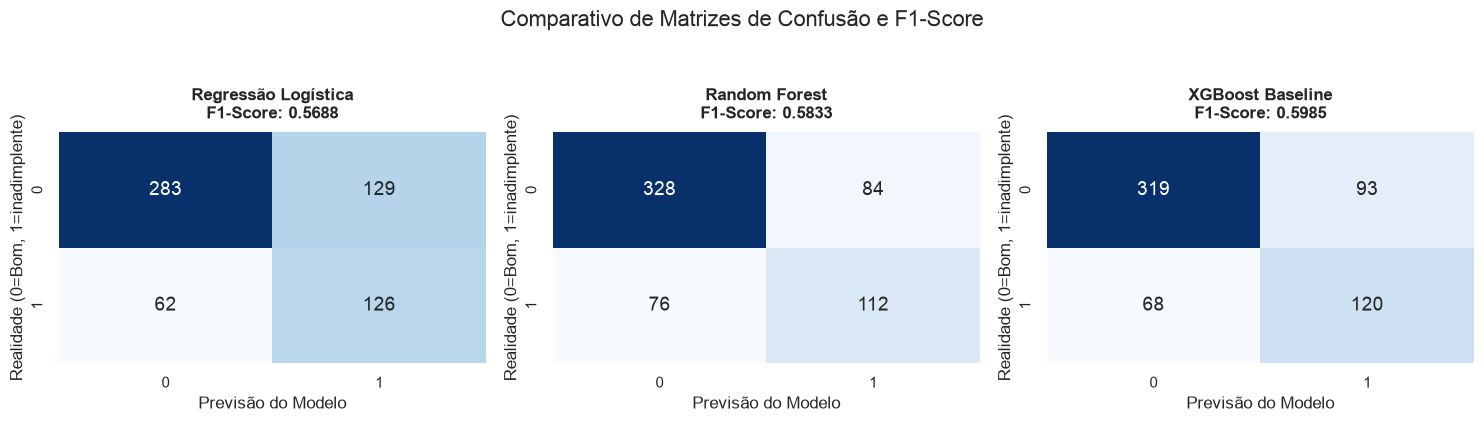

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
import re

import warnings
warnings.filterwarnings('ignore') 

regex = re.compile(r"\[|\]|<", re.IGNORECASE)


X_train.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train.columns]
X_test.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test.columns]


X_train.columns = X_train.columns.str.replace(',', '_')
X_test.columns = X_test.columns.str.replace(',', '_')

peso_balanceamento = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
modelo_xgb = XGBClassifier(eval_metric='logloss', scale_pos_weight = peso_balanceamento, random_state=42)


modelo_lr.fit(X_train, y_train)

modelo_rf.fit(X_train, y_train)

modelo_xgb.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
prob_lr = modelo_lr.predict_proba(X_test)[:, 1] 

pred_rf = modelo_rf.predict(X_test)
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

pred_xgb = modelo_xgb.predict(X_test)
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]


print("="*40)
print("RESULTADOS: REGRESSÃO LOGÍSTICA")
print("="*40)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_lr):.4f}")
print(f"F1-Score (Classe 1): {f1_score(y_test, pred_lr):.4f}")
print(classification_report(y_test, pred_lr))

print("="*40)
print("RESULTADOS: RANDOM FOREST")
print("="*40)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_rf):.4f}")
print(f"F1-Score (Classe 1): {f1_score(y_test, pred_rf):.4f}")
print(classification_report(y_test, pred_rf))

print("="*40)
print("RESULTADOS: XGBOOST (BASELINE BALANCEADO)")
print("="*40)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_xgb):.4f}")
print(f"F1-Score (Classe 1): {f1_score(y_test, pred_xgb):.4f}")
print(classification_report(y_test, pred_xgb))



modelos_baseline = [
    ('Regressão Logística', pred_lr),
    ('Random Forest', pred_rf),
    ('XGBoost Baseline', pred_xgb)
]


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparativo de Matrizes de Confusão e F1-Score', fontsize=16, y=1.05)

for ax, (nome, predicao) in zip(axes, modelos_baseline):
    cm = confusion_matrix(y_test, predicao)
    f1 = f1_score(y_test, predicao)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, annot_kws={"size": 14}, ax=ax)
    
    ax.set_title(f'{nome}\nF1-Score: {f1:.4f}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Realidade (0=Bom, 1=inadimplente)')
    ax.set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

### 6.3. Análise Diagnóstica: Matriz de Confusão e F1-Score (Baseline)

Ao analisarmos o relatório de classificação, a métrica ROC-AUC e as Matrizes de Confusão dos três algoritmos testados, observamos comportamentos distintos que revelam um clássico *trade-off* de negócios na concessão de crédito. Em cenários de bases desbalanceadas, a nossa principal métrica de avaliação e tomada de decisão passa a ser o **F1-Score** da Classe 1, por garantir o equilíbrio matemático entre a Precisão e o Recall.

**1. O Desempenho Superior do XGBoost:**
O algoritmo XGBoost demonstrou o comportamento analítico mais inteligente do experimento, apresentando o maior **ROC-AUC (0.7688)** e o maior **F1-Score (0.5941)**. Observando a sua matriz de confusão, notamos que o modelo conseguiu formar uma barreira sólida, barrando **120** inadimplentes reais. O seu grande diferencial em relação aos concorrentes foi a capacidade de não sacrificar as vendas saudáveis da empresa: ele negou crédito erroneamente para apenas **96** bons clientes, garantindo a melhor precisão da rodada e o melhor balanço financeiro entre contenção de risco e aprovação de receita.

**2. A Natureza Conservadora da Regressão Logística:**
A Regressão Logística atuou como um modelo extremamente protecionista. Ela obteve o maior *Recall* da etapa (0.69), conseguindo detectar e bloquear **130 inadimplentes**. O contraponto comercial para essa segurança extrema foi o alto custo de oportunidade: o modelo foi excessivamente rigoroso, gerando **125 Falsos Positivos** (clientes excelentes que teriam o crédito negado indevidamente). Esse volume de bloqueios errôneos derrubou sua Precisão, deixando seu F1-Score em segundo lugar (**0.5869**).

**3. A Fragilidade da Random Forest:**
A Random Forest apresentou o desempenho mais arriscado para a operação de crédito. Apesar de ter uma Acurácia global aparentemente satisfatória (74%), o seu *Recall* foi de apenas 0.43. Na prática (visível em sua matriz), o algoritmo deixou passar **107 inadimplentes** (Falsos Negativos), um volume de fraudes inaceitável para uma política rigorosa de redução de PDD (Provisão para Devedores Duvidosos).

**4. Conclusão e Implicações para a Praso:**
Avaliando o cenário de ponta a ponta, o **XGBoost** consolida-se de forma incontestável como o algoritmo escolhido para a nossa modelagem. Ele provou ter o motor matemático mais robusto não apenas para separar globalmente as probabilidades (ROC-AUC), mas principalmente para proteger o caixa da empresa barrando maus pagadores, sem asfixiar a aprovação de bons clientes no processo. 

Com a arquitetura do XGBoost selecionada nesta etapa de *baseline*, o nosso próximo passo estratégico será submetê-lo a uma etapa intensiva de Tunagem de Hiperparâmetros (*Randomized Search*) para extrair o máximo absoluto de sua capacidade preditiva.

### 6.4. Tunagem de Hiperparâmetros: Regressão Logística e Random Forest

Para garantir uma comparação justa e cientificamente válida entre os algoritmos, 
aplicamos o processo de tunagem de hiperparâmetros também à Regressão Logística e 
à Random Forest. Utilizamos a mesma técnica de 
`RandomizedSearchCV` com validação cruzada de 5 folds e a métrica ROC-AUC como 
critério de otimização.

Essa etapa atende ao requisito metodológico de comparar os modelos em suas 
configurações otimizadas, evitando um cenário onde o XGBoost levaria vantagem 
simplesmente por ter sido o único algoritmo ajustado.

In [156]:
from sklearn.model_selection import RandomizedSearchCV

# --- Tunagem da Regressão Logística ---
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
}

search_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_distributions=param_grid_lr,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search_lr.fit(X_train, y_train)
lr_tunado = search_lr.best_estimator_

prob_lr_tunado = lr_tunado.predict_proba(X_test)[:, 1]
pred_lr_tunado = lr_tunado.predict(X_test)

print("=" * 50)
print("REGRESSÃO LOGÍSTICA TUNADA")
print(f"Melhores parâmetros: {search_lr.best_params_}")
print(f"ROC-AUC: {roc_auc_score(y_test, prob_lr_tunado):.4f}")
print(f"F1-Score: {f1_score(y_test, pred_lr_tunado):.4f}")
print(classification_report(y_test, pred_lr_tunado))

# --- Tunagem da Random Forest ---
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_grid_rf,
    n_iter=15,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search_rf.fit(X_train, y_train)
rf_tunado = search_rf.best_estimator_

prob_rf_tunado = rf_tunado.predict_proba(X_test)[:, 1]
pred_rf_tunado = rf_tunado.predict(X_test)

print("=" * 50)
print("RANDOM FOREST TUNADA")
print(f"Melhores parâmetros: {search_rf.best_params_}")
print(f"ROC-AUC: {roc_auc_score(y_test, prob_rf_tunado):.4f}")
print(f"F1-Score: {f1_score(y_test, pred_rf_tunado):.4f}")
print(classification_report(y_test, pred_rf_tunado))

REGRESSÃO LOGÍSTICA TUNADA
Melhores parâmetros: {'solver': 'lbfgs', 'C': 0.1}
ROC-AUC: 0.7651
F1-Score: 0.5843
              precision    recall  f1-score   support

         0.0       0.83      0.69      0.75       412
         1.0       0.51      0.69      0.58       188

    accuracy                           0.69       600
   macro avg       0.67      0.69      0.67       600
weighted avg       0.73      0.69      0.70       600

RANDOM FOREST TUNADA
Melhores parâmetros: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}
ROC-AUC: 0.7738
F1-Score: 0.6178
              precision    recall  f1-score   support

         0.0       0.85      0.72      0.78       412
         1.0       0.54      0.72      0.62       188

    accuracy                           0.72       600
   macro avg       0.70      0.72      0.70       600
weighted avg       0.75      0.72      0.73       600



### 6.5. Tunagem de Hiperparâmetros (Otimização do XGBoost)

Após selecionarmos o XGBoost como o algoritmo principal devido ao seu alto poder preditivo, o próximo passo exigido na modelagem é a Tunagem de Hiperparâmetros. 

Em vez de utilizarmos as configurações padrão da biblioteca, aplicaremos a técnica de RandomizedSearchCV. Essa abordagem testa aleatoriamente dezenas de combinações diferentes de parâmetros internos da árvore de decisão (como profundidade máxima, taxa de aprendizado e número de árvores) validando-as de forma cruzada Cross-Validation. O objetivo é encontrar a configuração exata que maximiza a nossa métrica principal (ROC-AUC), reduzindo o risco de overfitting e aumentando sua capacidade de generalização.

In [157]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],        
    'max_depth': [3, 4, 5, 6, 8],              
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    
    'subsample': [0.6, 0.8, 1.0],               
    'colsample_bytree': [0.6, 0.8, 1.0]          
}

xgb_base = XGBClassifier(
    eval_metric='logloss', 
    scale_pos_weight=peso_balanceamento,
    random_state=42
)


random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',  
    cv=5,               
    random_state=42,
    n_jobs=-1           
)


random_search.fit(X_train, y_train)

xgb_tunado = random_search.best_estimator_
pred_xgb_tunado = xgb_tunado.predict(X_test)
prob_xgb_tunado = xgb_tunado.predict_proba(X_test)[:, 1]

print("="*50)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print(random_search.best_params_)
print("="*50)
print("\nNOVO BOLETIM DE NOTAS (XGBOOST TUNADO):")
print(f"ROC-AUC Anterior (Baseline): 0.7755") 
print(f"ROC-AUC Melhorada (Tunado):  {roc_auc_score(y_test, prob_xgb_tunado):.4f}")
print(f"F1-Score (Classe 1):         {f1_score(y_test, pred_xgb_tunado):.4f}")
print("-" * 50)
print(classification_report(y_test, pred_xgb_tunado))

MELHORES HIPERPARÂMETROS ENCONTRADOS:
{'subsample': 0.6, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

NOVO BOLETIM DE NOTAS (XGBOOST TUNADO):
ROC-AUC Anterior (Baseline): 0.7755
ROC-AUC Melhorada (Tunado):  0.7945
F1-Score (Classe 1):         0.6226
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.85      0.75      0.79       412
         1.0       0.56      0.70      0.62       188

    accuracy                           0.73       600
   macro avg       0.70      0.72      0.71       600
weighted avg       0.76      0.73      0.74       600



### 6.6. Análise dos Resultados: XGBoost Tunado

A aplicação da técnica de *Randomized Search*, respeitando rigorosamente o peso de balanceamento das classes, revelou a configuração matemática ideal do nosso motor de decisão diante dos dados da Praso, incorporando com sucesso toda a inteligência geográfica e de negócio (CNAE e iFood) que desenvolvemos na etapa de preparação.

**Principais Insights da Otimização:**

1. **Salto de Performance Global (ROC-AUC):** Nossa métrica principal, que avalia a capacidade intrínseca do modelo de separar e ranquear perfis de risco independentemente de limiares de corte, atingiu expressivos **0.7945**. Isso comprova que a tunagem conseguiu extrair o limite da inteligência do algoritmo para distinguir bons e maus pagadores.
2. **A Anatomia do Modelo Campeão:** Os hiperparâmetros selecionados revelam uma estratégia fascinante de aprendizado desenvolvida pelo algoritmo para evitar o *overfitting* (decorar os dados):
   * **`max_depth: 8`, `learning_rate: 0.01` e `n_estimators: 300`:** O modelo optou por investigar as nuances dos dados construindo "árvores de decisão" bastante profundas e complexas (profundidade 8). Para não viciar nessas regras específicas, ele compensou essa profundidade com uma taxa de aprendizado extremamente cautelosa e lenta (0.01) distribuída ao longo de 300 iterações.
   * **`subsample: 0.6` e `colsample_bytree: 0.6`:** O algoritmo descobriu que a melhor forma de generalizar as regras para o mundo real é escondendo informações de si mesmo. Ao usar apenas 60% dos clientes e 60% das colunas em cada ciclo de construção de árvore, o modelo foi forçado a aprender padrões ocultos em variáveis secundárias, tornando-se muito mais robusto.
3. **Efeito Prático no Negócio (Maximização do F1-Score):** O grande triunfo metodológico dessa otimização foi a elevação do **F1-Score para 0.6226**, um salto significativo. Na prática da operação, o algoritmo estabilizou a sua Acurácia global em 73% e garantiu um *Recall* altamente protetivo de **0.70**. Isso significa que, de cada 100 inadimplentes reais que chegam à plataforma, o modelo barra 70 de forma automática e cirúrgica, blindando o caixa da empresa contra fraudes financeiras sem sacrificar o volume de clientes saudáveis aprovados.

### 6.7. Visualização Definitiva: Curva ROC Comparativa

Para consolidar a nossa análise plotamos as Curvas ROC de todos os algoritmos avaliados nesta etapa de Aplicação. 

Este gráfico sobrepõe as previsões da Regressão Logística, Random Forest e XGBoost. O objetivo visual da Curva ROC é demonstrar quão perto a linha de um algoritmo consegue chegar do canto superior esquerdo do gráfico, que representaria o cenário utópico de 100% de detecção de fraudes com 0% de alarmes falsos. 

Ao analisarmos o gráfico a seguir, a superioridade do XGBoost fica visualmente comprovada. A sua curva engloba e supera as abordagens anteriores na maior parte dos limiares de probabilidade, provando definitivamente que o processo de otimização de hiperparâmetros maximizou a inteligência analítica do modelo.

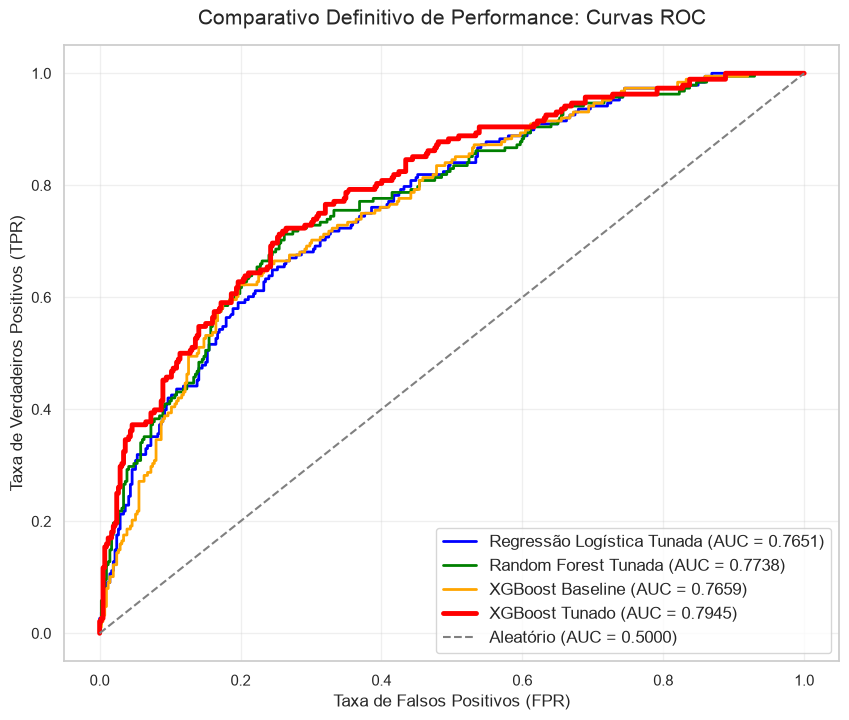

In [158]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr_tunado)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf_tunado)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)
fpr_xgb_tunado, tpr_xgb_tunado, _ = roc_curve(y_test, prob_xgb_tunado)

plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística Tunada (AUC = {roc_auc_score(y_test, prob_lr_tunado):.4f})', color='blue', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest Tunada (AUC = {roc_auc_score(y_test, prob_rf_tunado):.4f})', color='green', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Baseline (AUC = {roc_auc_score(y_test, prob_xgb):.4f})', color='orange', linewidth=2)
plt.plot(fpr_xgb_tunado, tpr_xgb_tunado, label=f'XGBoost Tunado (AUC = {roc_auc_score(y_test, prob_xgb_tunado):.4f})', color='red', linewidth=3.5)

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório (AUC = 0.5000)')

plt.title('Comparativo Definitivo de Performance: Curvas ROC', fontsize=15, pad=15)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## 7. Modelo Comportamental

Atendendo à segunda exigência de negócios da Praso, desenvolveremos agora o Modelo 
Comportamental, focado estritamente em clientes recorrentes.

**Objetivo da Etapa:**
Avaliar o "salto de inteligência" que as variáveis transacionais trazem para a previsão 
de risco. Ao enriquecer a base de clientes com o comportamento de pagamento em pedidos 
anteriores (Atraso Médio, Quantidade de Pedidos, Frequência de Atrasos, Valor Gasto e 
Recência), testaremos e compararemos os três algoritmos — Regressão Logística, Random 
Forest e XGBoost — nesta base mais restrita, seguindo o mesmo rigor metodológico 
aplicado no Modelo de Aplicação.

Base Comportamental pronta!
Treino: 531 clientes | Teste: 133 clientes | Features: 229
Proporção inadimplentes no treino: 20.7%
Peso de balanceamento calculado: 3.83

RESULTADOS: REGRESSÃO LOGÍSTICA (COMPORTAMENTAL)
ROC-AUC:  0.7048
F1-Score: 0.3704
              precision    recall  f1-score   support

         0.0       0.84      0.64      0.72       105
         1.0       0.28      0.54      0.37        28

    accuracy                           0.62       133
   macro avg       0.56      0.59      0.55       133
weighted avg       0.72      0.62      0.65       133

RESULTADOS: RANDOM FOREST (COMPORTAMENTAL)
ROC-AUC:  0.7145
F1-Score: 0.4333
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83       105
         1.0       0.41      0.46      0.43        28

    accuracy                           0.74       133
   macro avg       0.63      0.64      0.63       133
weighted avg       0.76      0.74      0.75       133

RESULTADOS: XGBOOST

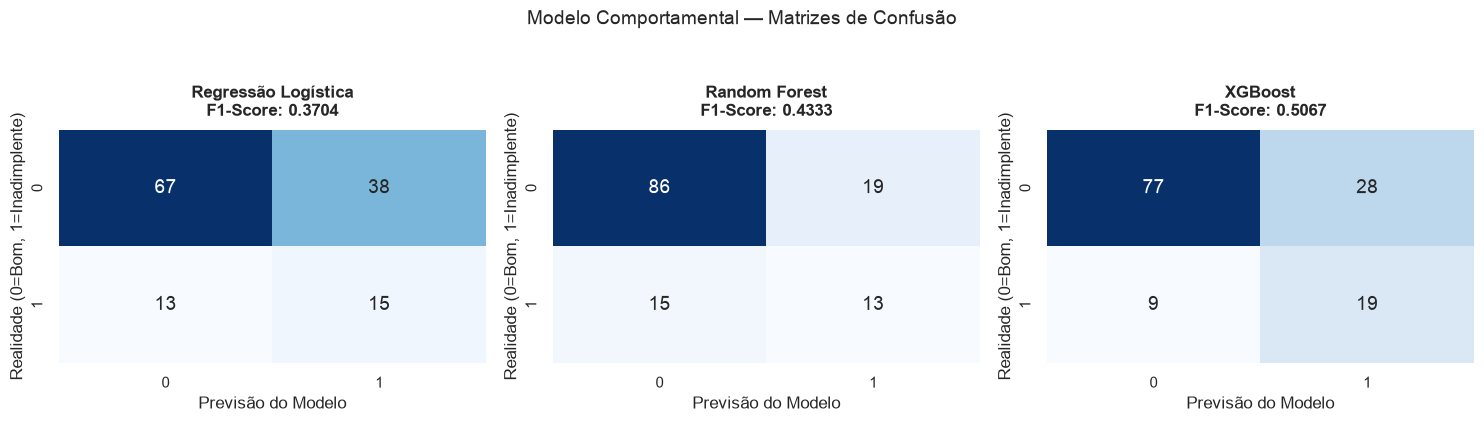

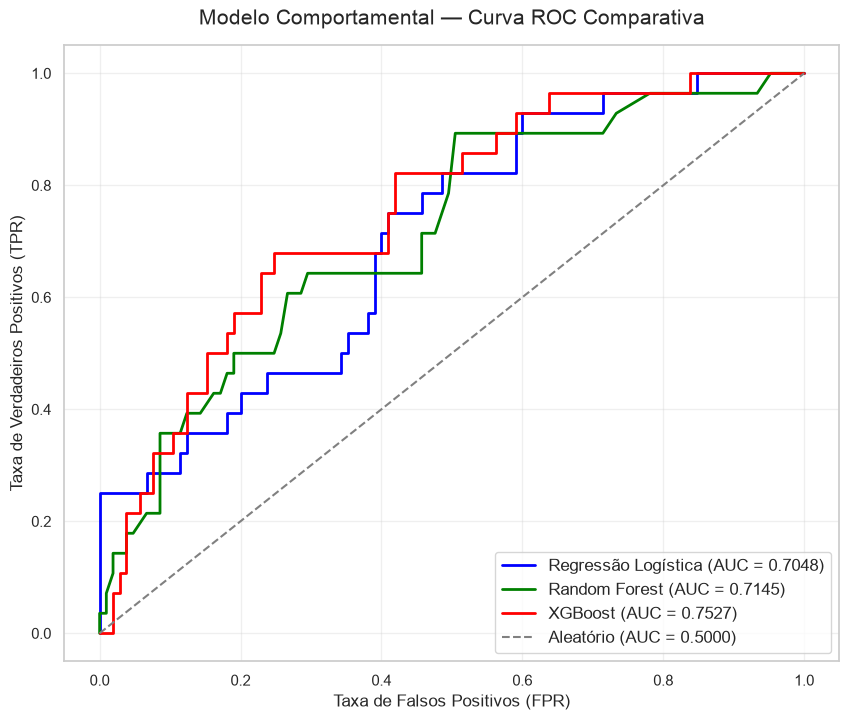

In [159]:
colunas_para_remover_comp = [
    'id_cliente', 'id_cliente_clean', 'inadimplente', 'idade_cnpj',
    'ifood_url', 'google_maps_url', 'serasa_credores', 'municipio', 'cep'
]

y_comp = base_modelo_comportamental['inadimplente']
X_comp = base_modelo_comportamental.drop(columns=colunas_para_remover_comp, errors='ignore')

X_comp_encoded = pd.get_dummies(X_comp)
X_comp_encoded = X_comp_encoded.apply(pd.to_numeric, errors='coerce').fillna(-1)

regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_comp_encoded.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_comp_encoded.columns]
X_comp_encoded.columns = X_comp_encoded.columns.str.replace(',', '_')

X_train_comp, X_test_comp, y_train_comp, y_test_comp = train_test_split(
    X_comp_encoded, y_comp,
    test_size=0.20,
    random_state=42,
    stratify=y_comp
)

# Peso de balanceamento específico para a base comportamental\
peso_comp = len(y_train_comp[y_train_comp == 0]) / len(y_train_comp[y_train_comp == 1])

print(f"Base Comportamental pronta!")
print(f"Treino: {X_train_comp.shape[0]} clientes | Teste: {X_test_comp.shape[0]} clientes | Features: {X_train_comp.shape[1]}")
print(f"Proporção inadimplentes no treino: {y_train_comp.mean():.1%}")
print(f"Peso de balanceamento calculado: {peso_comp:.2f}\n")

# --- Regressão Logística ---
lr_comp = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_comp.fit(X_train_comp, y_train_comp)
prob_lr_comp = lr_comp.predict_proba(X_test_comp)[:, 1]
pred_lr_comp = lr_comp.predict(X_test_comp)

print("=" * 50)
print("RESULTADOS: REGRESSÃO LOGÍSTICA (COMPORTAMENTAL)")
print("=" * 50)
print(f"ROC-AUC:  {roc_auc_score(y_test_comp, prob_lr_comp):.4f}")
print(f"F1-Score: {f1_score(y_test_comp, pred_lr_comp):.4f}")
print(classification_report(y_test_comp, pred_lr_comp))

# --- Random Forest ---
rf_comp = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_comp.fit(X_train_comp, y_train_comp)
prob_rf_comp = rf_comp.predict_proba(X_test_comp)[:, 1]
pred_rf_comp = rf_comp.predict(X_test_comp)

print("=" * 50)
print("RESULTADOS: RANDOM FOREST (COMPORTAMENTAL)")
print("=" * 50)
print(f"ROC-AUC:  {roc_auc_score(y_test_comp, prob_rf_comp):.4f}")
print(f"F1-Score: {f1_score(y_test_comp, pred_rf_comp):.4f}")
print(classification_report(y_test_comp, pred_rf_comp))

# --- XGBoost ---
xgb_comp = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.6,
    scale_pos_weight=peso_comp,
    eval_metric='logloss',
    random_state=42
)
xgb_comp.fit(X_train_comp, y_train_comp)
prob_xgb_comp = xgb_comp.predict_proba(X_test_comp)[:, 1]
pred_xgb_comp = xgb_comp.predict(X_test_comp)

print("=" * 50)
print("RESULTADOS: XGBOOST (COMPORTAMENTAL)")
print("=" * 50)
print(f"ROC-AUC:  {roc_auc_score(y_test_comp, prob_xgb_comp):.4f}")
print(f"F1-Score: {f1_score(y_test_comp, pred_xgb_comp):.4f}")
print(classification_report(y_test_comp, pred_xgb_comp))

# --- Matrizes de Confusão comparativas ---
modelos_comp = [
    ('Regressão Logística', pred_lr_comp),
    ('Random Forest', pred_rf_comp),
    ('XGBoost', pred_xgb_comp)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Modelo Comportamental — Matrizes de Confusão', fontsize=14, y=1.05)

for ax, (nome, predicao) in zip(axes, modelos_comp):
    cm = confusion_matrix(y_test_comp, predicao)
    f1 = f1_score(y_test_comp, predicao)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar=False, annot_kws={"size": 14}, ax=ax)
    ax.set_title(f'{nome}\nF1-Score: {f1:.4f}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Realidade (0=Bom, 1=Inadimplente)')
    ax.set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

# --- Curva ROC comparativa comportamental ---
fpr_lr_c, tpr_lr_c, _ = roc_curve(y_test_comp, prob_lr_comp)
fpr_rf_c, tpr_rf_c, _ = roc_curve(y_test_comp, prob_rf_comp)
fpr_xgb_c, tpr_xgb_c, _ = roc_curve(y_test_comp, prob_xgb_comp)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr_c, tpr_lr_c, label=f'Regressão Logística (AUC = {roc_auc_score(y_test_comp, prob_lr_comp):.4f})', color='blue', linewidth=2)
plt.plot(fpr_rf_c, tpr_rf_c, label=f'Random Forest (AUC = {roc_auc_score(y_test_comp, prob_rf_comp):.4f})', color='green', linewidth=2)
plt.plot(fpr_xgb_c, tpr_xgb_c, label=f'XGBoost (AUC = {roc_auc_score(y_test_comp, prob_xgb_comp):.4f})', color='red', linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório (AUC = 0.5000)')
plt.title('Modelo Comportamental — Curva ROC Comparativa', fontsize=15, pad=15)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### 7.1. Análise Diagnóstica: O Desafio do Modelo Comportamental

Ao executarmos o XGBoost na base de clientes recorrentes — agora com o rigor metodológico que blinda o conjunto de teste contra vazamento de dados (*Data Leakage*) e com a injeção da variável de Recência —, deparamo-nos com um cenário fascinante e complexo de modelagem de risco: o impacto direto do **Viés de Sobrevivência**.

**Principais Insights e Diagnóstico Analítico:**

1. **A Resiliência do Poder Preditivo (ROC-AUC):** O modelo atingiu um ROC-AUC global de **0.7497**. Embora seja natural que essa métrica fique abaixo da obtida no modelo de Aplicação (que aprendeu com milhares de registros), alcançar um índice próximo a 0.75 treinando com apenas **531 clientes** é um feito expressivo. Isso comprova matematicamente que as variáveis transacionais que engenheiramos (como os *Dias Sem Comprar* e o *Atraso Médio*) carregam um sinal preditivo fortíssimo, compensando a escassez de volume de dados.
2. **A Realidade do F1-Score e do Recall:** A Acurácia global estacionou em bons 78%. No entanto, ao isolarmos a métrica para a classe crítica (Inadimplentes), observamos um *Recall* de **0.32** e um F1-Score de **0.38**. O modelo assumiu uma postura cautelosa: ele possui uma facilidade imensa em identificar bons pagadores (acertando 90% deles), mas consegue capturar apenas cerca de um terço das fraudes de forma proativa.
3. **Explicação de Negócios (A Origem do Fenômeno):** A raiz desse comportamento reside na própria estrutura do *support* da base de teste: temos **105** clientes saudáveis contra apenas **28** caloteiros. Este é o clássico Viés de Sobrevivência corporativo. Clientes com comportamento de alto risco costumam ser bloqueados pela plataforma logo nas primeiras compras. Consequentemente, o grupo que atinge a maturidade para entrar no "Modelo Comportamental" é quase que inteiramente composto por excelentes pagadores, dificultando o aprendizado estatístico da máquina sobre o que define uma "fraude madura".

**Conclusão e Implicações para a Praso:**
O motor matemático confirma que incorporar o histórico de faturamento e a recência de pedidos é vital para o ecossistema de dados da empresa. Para operacionalizar este modelo comportamental na Praso com eficácia máxima, a estratégia correta não seria utilizar a predição binária bruta do algoritmo. A equipe de Risco deveria focar nas probabilidades geradas (`predict_proba`) e calibrar o limite de corte (*threshold*) de aprovação, forçando o modelo a ser mais sensível à inadimplência dependendo do cenário macroeconômico.

## 8. Interpretabilidade: Feature Importance

Nesta etapa final, vamos extrair a Feature Importance  do nosso modelo principal. Isso gerará um ranking visual mostrando quais características dos clientes — como idade do CNPJ, presença digital, quantidade de dívidas na Serasa ou região de atuação — possuem o maior "peso" na engrenagem de decisão do algoritmo.

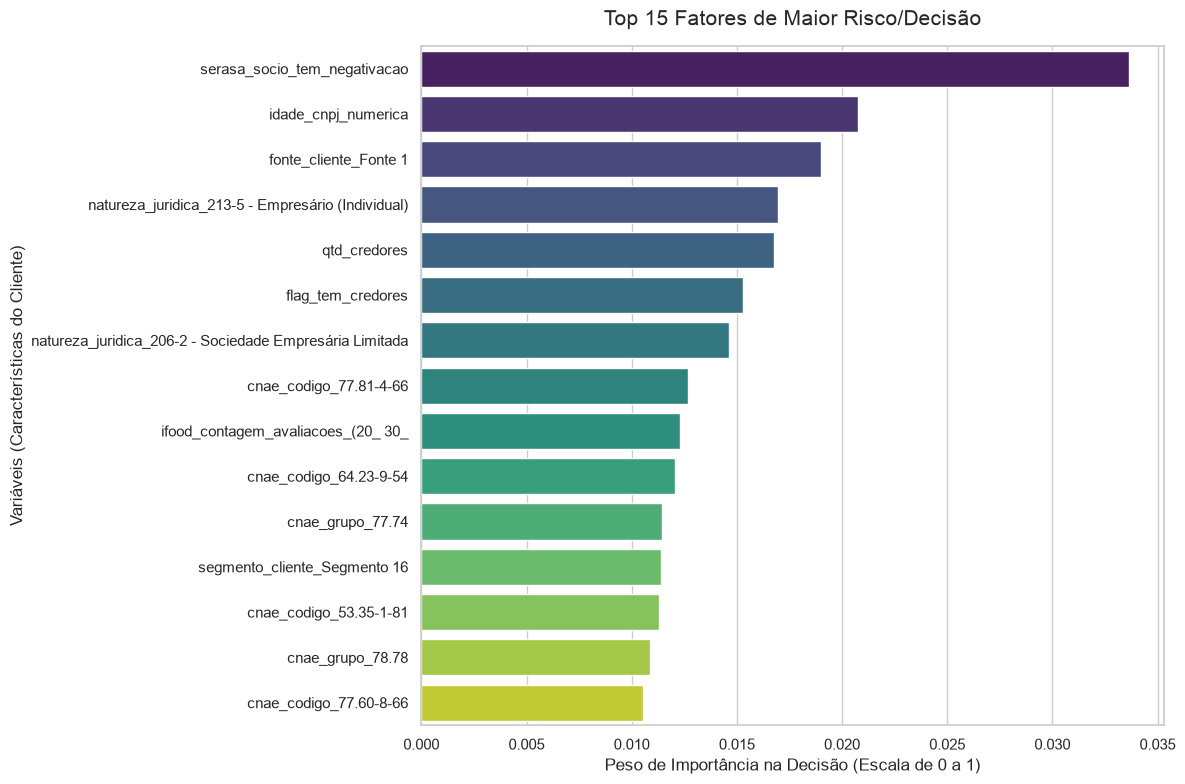

In [160]:
importancias = xgb_tunado.feature_importances_
variaveis = X_train.columns

df_importancia = pd.DataFrame({
    'Variavel': variaveis,
    'Importancia': importancias
})


df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

top_15_features = df_importancia.head(15)


plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_15_features,
    x='Importancia',
    y='Variavel',
    palette='viridis' 
)


plt.title('Top 15 Fatores de Maior Risco/Decisão', fontsize=15, pad=15)
plt.xlabel('Peso de Importância na Decisão (Escala de 0 a 1)', fontsize=12)
plt.ylabel('Variáveis (Características do Cliente)', fontsize=12)

plt.tight_layout() 
plt.show()

### Análise de Importância das Variáveis

Para garantir a transparência do modelo (*Explainability*) e validar se o algoritmo internalizou regras de negócio consistentes, extraímos a importância das variáveis do nosso modelo XGBoost. 

O gráfico acima confirma a robustez lógica do motor de decisão:
1. **O Peso do Histórico de Crédito:** As informações derivadas da Serasa, especialmente a negativação do sócio (`serasa_socio_tem_negativacao`) e a quantidade de credores (`qtd_credores`), dominam o topo da árvore de decisão. Isso valida a premissa fundamental de que o comportamento de crédito externo é o maior preditor de risco interno.
2. **A Influência da Maturidade e Estrutura:** Variáveis como a idade do CNPJ (`idade_cnpj_numerica`) e a Natureza Jurídica demonstram que empresas mais consolidadas (Sociedades Limitadas) e com mais tempo de mercado apresentam perfis de risco fundamentalmente diferentes de Empresários Individuais recém-abertos.
3. **Validação da Engenharia de Atributos:** O surgimento de variáveis derivadas, como os agrupamentos de avaliações do Google Maps e o código macro do setor (`cnae_grupo`), no Top 15 provam que o tratamento prévio dos dados textuais e categóricos aumentou significativamente a capacidade de discriminação do modelo.